In [103]:
import pandas as pd
import numpy as np

df = pd.read_csv('gold_cleaned_with_sentiment_onehot_finbert.csv')

df

,date,Close,High,Low,Open,Volume,majority_vote_score,negative,neutral,positive
0,2004-01-05,424.399994,422.500000,422.500000,415.700012,20,-1.0,1,0,0
1,2004-01-06,422.799988,424.299988,424.299988,424.399994,20,-1.0,1,0,0
2,2004-01-07,421.899994,423.000000,423.000000,423.000000,20,-1.0,1,0,0
3,2004-01-08,424.000000,422.000000,422.000000,421.899994,20,-1.0,1,0,0
4,2004-01-09,426.399994,423.899994,423.899994,424.000000,20,-1.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
5268,2024-12-23,2612.300049,2627.699951,2611.100098,2620.000000,451,-1.0,1,0,0
5269,2024-12-24,2620.000000,2620.000000,2609.500000,2613.000000,35,-1.0,1,0,0
5270,2024-12-26,2638.800049,2638.800049,2627.899902,2628.500000,84,-1.0,1,0,0
5271,2024-12-27,2617.199951,2617.699951,2616.399902,2617.699951,642,1.0,0,0,1


In [104]:
df = df[['date', 'Open', 'Close', 'negative', 'neutral', 'positive']]

df

,date,Open,Close,negative,neutral,positive
0,2004-01-05,415.700012,424.399994,1,0,0
1,2004-01-06,424.399994,422.799988,1,0,0
2,2004-01-07,423.000000,421.899994,1,0,0
3,2004-01-08,421.899994,424.000000,1,0,0
4,2004-01-09,424.000000,426.399994,1,0,0
...,...,...,...,...,...,...
5268,2024-12-23,2620.000000,2612.300049,1,0,0
5269,2024-12-24,2613.000000,2620.000000,1,0,0
5270,2024-12-26,2628.500000,2638.800049,1,0,0
5271,2024-12-27,2617.699951,2617.199951,0,0,1


In [105]:
df['date']

0       2004-01-05
1       2004-01-06
2       2004-01-07
3       2004-01-08
4       2004-01-09
           ...    
5268    2024-12-23
5269    2024-12-24
5270    2024-12-26
5271    2024-12-27
5272    2024-12-30
Name: date, Length: 5273, dtype: object

In [106]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [107]:
df

,date,Open,Close,negative,neutral,positive
0,2004-01-05,415.700012,424.399994,1,0,0
1,2004-01-06,424.399994,422.799988,1,0,0
2,2004-01-07,423.000000,421.899994,1,0,0
3,2004-01-08,421.899994,424.000000,1,0,0
4,2004-01-09,424.000000,426.399994,1,0,0
...,...,...,...,...,...,...
5268,2024-12-23,2620.000000,2612.300049,1,0,0
5269,2024-12-24,2613.000000,2620.000000,1,0,0
5270,2024-12-26,2628.500000,2638.800049,1,0,0
5271,2024-12-27,2617.699951,2617.199951,0,0,1


In [108]:
df['date'] = df['date'].apply(str_to_datetime)
df['date']

C:\Users\umuro\AppData\Local\Temp\ipykernel_22952\3235390050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date'].apply(str_to_datetime)


0      2004-01-05
1      2004-01-06
2      2004-01-07
3      2004-01-08
4      2004-01-09
          ...    
5268   2024-12-23
5269   2024-12-24
5270   2024-12-26
5271   2024-12-27
5272   2024-12-30
Name: date, Length: 5273, dtype: datetime64[ns]

In [109]:
df.index = df.pop('date')
df

,Open,Close,negative,neutral,positive
date,,,,,
2004-01-05,415.700012,424.399994,1,0,0
2004-01-06,424.399994,422.799988,1,0,0
2004-01-07,423.000000,421.899994,1,0,0
2004-01-08,421.899994,424.000000,1,0,0
2004-01-09,424.000000,426.399994,1,0,0
...,...,...,...,...,...
2024-12-23,2620.000000,2612.300049,1,0,0
2024-12-24,2613.000000,2620.000000,1,0,0
2024-12-26,2628.500000,2638.800049,1,0,0


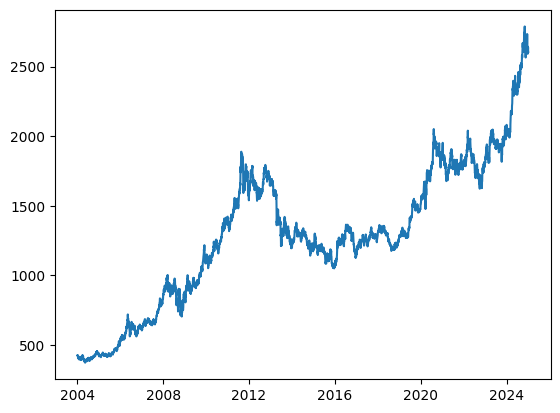

In [110]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Close'])

In [111]:
def df_to_windowed_df_fast(dataframe, n=3, features=['Close']):
    X, Y, dates = [], [], []
    for i in range(n, len(dataframe)):
        x_feats = []
        for feature in features:
            x_feats.extend(dataframe[feature].iloc[i-n:i].to_numpy())
        x = np.array(x_feats)
        y = dataframe['Close'].iloc[i]
        date = dataframe.index[i]
        X.append(x)
        Y.append(y)
        dates.append(date)

    X = np.array(X)
    ret_df = pd.DataFrame({'Target Date': dates})
    for j in range(X.shape[1]):
        ret_df[f'Feature_{j}'] = X[:, j]
    ret_df['Target'] = Y
    return ret_df
print(df.columns)
windowed_df = df_to_windowed_df_fast(df, n=10, features=['Close', 'Open'])


Index(['Open', 'Close', 'negative', 'neutral', 'positive'], dtype='object')


In [112]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((5263,), (5263, 20, 1), (5263,))

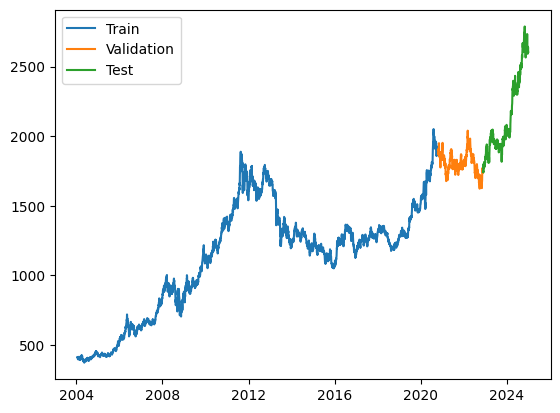

In [113]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(128),
                    layers.Dense(64, activation='relu'),
                    layers.Dense(64, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1364323.0000 - mean_absolute_error: 1096.5367 - val_loss: 1746980.0000 - val_mean_absolute_error: 1319.5706
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 316637.0938 - mean_absolute_error: 466.6629 - val_loss: 249102.4688 - val_mean_absolute_error: 493.4709
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 27017.0059 - mean_absolute_error: 106.9087 - val_loss: 52770.6406 - val_mean_absolute_error: 218.8157
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3250.1653 - mean_absolute_error: 34.4377 - val_loss: 13288.3438 - val_mean_absolute_error: 98.6893
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1933.1061 - mean_absolute_error: 29.9210 - val_loss: 10450.8438 - val_mean_absolute_error: 88.5346
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1139.0908 - mean_absolute_error: 22.7162 - val_loss: 4196.8081 - val_mean_absolute_error: 49.8848
Epoch 7/100
132/132

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


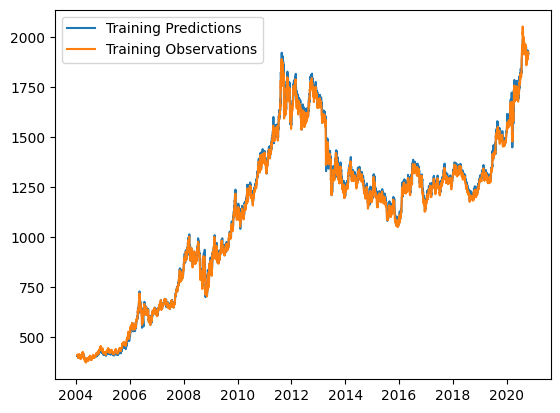

In [115]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


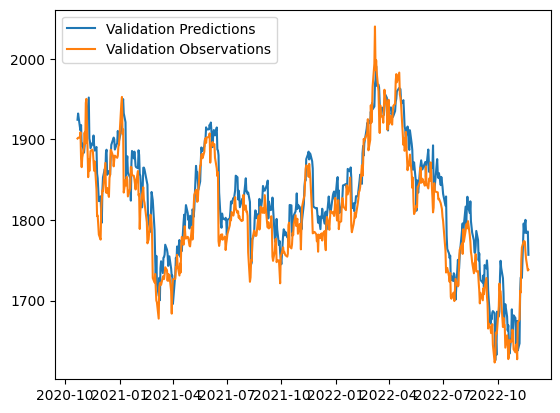

In [116]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


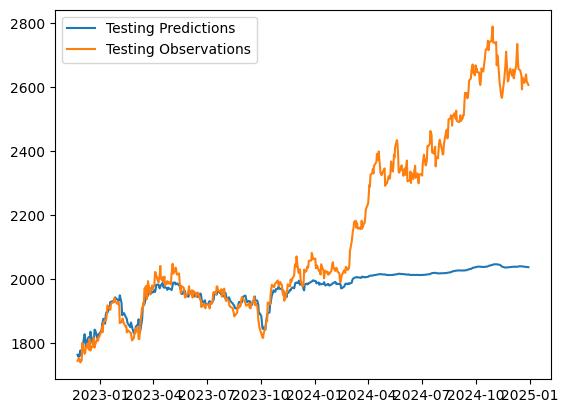

In [117]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

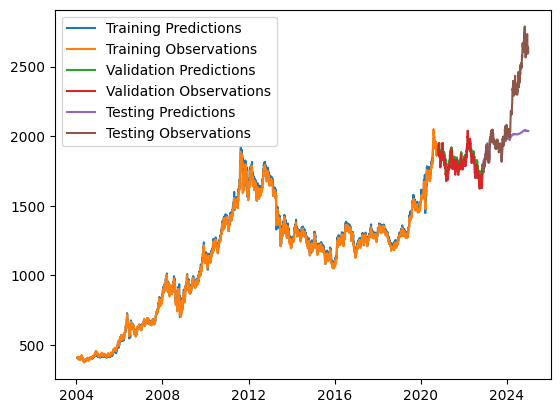

In [118]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions',
            'Training Observations',
            'Validation Predictions',
            'Validation Observations',
            'Testing Predictions',
            'Testing Observations'])